# Functional connectivity analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
#output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [3]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

window_size_tr = 6 # size of the correlation window in volumes
step_size_tr = 1   # step size of the correlation window in volumes

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1','corr_mt','corr_v1','corr_mt_coherent','corr_v1_coherent','corr_mt_incoherent','corr_v1_incoherent'])

# iterate over subjects
for ss,subject in enumerate(subject_list):

    print(f'Processing subject {subject} ({ss+1}/{len(subject_list)})')

    # iterate over trs
    for tt,tr in enumerate(tr_list):

        # iterate over runs
        for rr,run in enumerate(run_list):

            # load timecourse
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc_detrend.npy")
            tc = np.load(tc_file)

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # ----------------------------------------------------------------------------------------------------------------------------  

            # initialize correlation vectors
            corr_mt = np.zeros(int((tc[:,0].shape[0]-window_size_tr)/step_size_tr))
            corr_v1 = np.zeros(int((tc[:,0].shape[0]-window_size_tr)/step_size_tr))

            # estimate windowed correlation between left and right mt
            for tt,tt_vol in enumerate(range(0,tc[:,0].shape[0]-window_size_tr,step_size_tr)):
                corr_mt[tt] = np.corrcoef(tc[:,0][tt_vol:tt_vol+window_size_tr],tc[:,1][tt_vol:tt_vol+window_size_tr])[0,1]
                corr_v1[tt] = np.corrcoef(tc[:,2][tt_vol:tt_vol+window_size_tr],tc[:,3][tt_vol:tt_vol+window_size_tr])[0,1]

            # ----------------------------------------------------------------------------------------------------------------------------  
            
            # fetch events file
            task_label = f'task-{run}_acq-{round(tr*1000):04}_run-1'
            events_file = os.path.join(data_dir, subject, 'func', f'{subject}_{task_label}_events.tsv')

            events = pd.read_csv(events_file, sep='\t')

            # trim events to coherent and incoherent trial_types
            events = events.loc[events['trial_type'].isin(['coherent','incoherent'])]
            events = events.reset_index(drop=True)

            # trim events with duration < 7.5 seconds
            events = events.loc[events['duration']>=7.5]
            events = events.reset_index(drop=True)

            # get the indexes (based on the TR) for all coherent and incoherent trials
            coherent_idx = events.loc[events['trial_type']=='coherent']['onset'].values/tr
            coherent_idx = [int(x) for x in coherent_idx]
            incoherent_idx = events.loc[events['trial_type']=='incoherent']['onset'].values/tr
            incoherent_idx = [int(x) for x in incoherent_idx]

            # number of coherent trials
            n_coherent = len(coherent_idx)
            n_incoherent = len(incoherent_idx)

            # ----------------------------------------------------------------------------------------------------------------------------  

            # initialize correlation vectors for coherent and incoherent trials
            corr_mt_coherent = np.zeros((n_coherent,window_size_tr*2+1))
            corr_v1_coherent = np.zeros((n_coherent,window_size_tr*2+1))
            corr_mt_incoherent = np.zeros((n_incoherent,window_size_tr*2+1))
            corr_v1_incoherent = np.zeros((n_incoherent,window_size_tr*2+1))

            # iterate on the number of coherent trials
            for jj,coh_idx in enumerate(coherent_idx):

                # left_mt timecourse
                a = tc[:,0][coh_idx-window_size_tr:coh_idx+window_size_tr*2]
                # right_mt timecourse
                b = tc[:,1][coh_idx-window_size_tr:coh_idx+window_size_tr*2]
                # left_v1 timecourse
                c = tc[:,2][coh_idx-window_size_tr:coh_idx+window_size_tr*2]
                # right_v1 timecourse
                d = tc[:,3][coh_idx-window_size_tr:coh_idx+window_size_tr*2]

                # correlation per window of window_size_tr
                for kk in range(0,window_size_tr*2+1):
                    corr_mt_coherent[jj,kk] = np.corrcoef(a[kk:kk+window_size_tr],b[kk:kk+window_size_tr])[0,1]
                    corr_v1_coherent[jj,kk] = np.corrcoef(c[kk:kk+window_size_tr],d[kk:kk+window_size_tr])[0,1]

            # iterate on the number of incoherent trials
            for jj,incoh_idx in enumerate(incoherent_idx):

                # left_mt timecourse
                a = tc[:,0][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]
                # right_mt timecourse
                b = tc[:,1][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]
                # left_v1 timecourse
                c = tc[:,2][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]
                # right_v1 timecourse
                d = tc[:,3][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]

                # correlation per window of window_size_tr
                for kk in range(0,window_size_tr*2+1):
                    corr_mt_incoherent[jj,kk] = np.corrcoef(a[kk:kk+window_size_tr],b[kk:kk+window_size_tr])[0,1]
                    corr_v1_incoherent[jj,kk] = np.corrcoef(c[kk:kk+window_size_tr],d[kk:kk+window_size_tr])[0,1]

            # ----------------------------------------------------------------------------------------------------------------------------  

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2, corr_mt, corr_v1, corr_mt_coherent, corr_v1_coherent, corr_mt_incoherent, corr_v1_incoherent]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

Processing subject sub-01 (1/15)
Processing subject sub-02 (2/15)
Processing subject sub-03 (3/15)
Processing subject sub-05 (4/15)
Processing subject sub-06 (5/15)
Processing subject sub-07 (6/15)
Processing subject sub-08 (7/15)
Processing subject sub-10 (8/15)
Processing subject sub-11 (9/15)
Processing subject sub-12 (10/15)
Processing subject sub-15 (11/15)
Processing subject sub-16 (12/15)
Processing subject sub-21 (13/15)
Processing subject sub-22 (14/15)
Processing subject sub-23 (15/15)


In [5]:
df.head()

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1,corr_mt,corr_v1,corr_mt_coherent,corr_v1_coherent,corr_mt_incoherent,corr_v1_incoherent
0,sub-01,0.50,UA,"[-0.22502376, -0.75862014, -0.81892, 0.6557168...","[-0.29588887, -0.6328848, -1.0537118, -0.29287...","[0.007993267, 0.022420743, -0.31263652, -0.666...","[-0.061439723, -0.097172484, -0.0958057, -0.54...","[-0.26045632, -0.6957525, -0.9363159, 0.181421...","[-0.026723228, -0.03737587, -0.20422111, -0.60...","[0.8115215086648107, 0.7272282325693685, 0.830...","[0.943266662077711, 0.9543594200411416, 0.9346...","[[0.8421698737858649, 0.8532179394222907, 0.94...","[[0.9013158425023358, 0.904819692515268, 0.906...","[[0.29757264579902476, 0.8679391691608351, 0.9...","[[0.538678626266409, 0.5745218666822914, 0.724..."
1,sub-01,0.75,UA,"[-0.1484935, -0.16956916, 0.079313174, -0.1769...","[-0.14745189, -0.15049157, 0.3577576, 0.024255...","[0.06832045, 0.29584754, -1.2515142, -0.786156...","[-0.031186417, 0.1780903, -0.8298843, -0.43459...","[-0.1479727, -0.16003036, 0.2185354, -0.076326...","[0.018567018, 0.23696892, -1.0406992, -0.61037...","[0.6159483718782163, 0.6333025761723646, 0.510...","[0.9604088161096498, 0.974509624401947, 0.9781...","[[0.9799002451695892, 0.9894373463298721, 0.98...","[[0.18680795678014364, 0.5177248155670294, 0.8...","[[-0.4920268602104725, 0.7665094766256871, 0.8...","[[0.405042254560946, 0.14735451810558448, 0.53..."
2,sub-01,1.00,UA,"[0.031965997, -0.48273653, -0.8907577, 0.36385...","[0.061520167, 0.20370793, -0.8810853, 0.330087...","[-0.08184679, -0.25848472, -1.1230928, -0.5496...","[-0.018638223, 0.053932924, -0.9501851, -0.276...","[0.04674308, -0.1395143, -0.8859215, 0.3469732...","[-0.050242506, -0.1022759, -1.036639, -0.41311...","[0.8536320546904239, 0.8832512222690859, 0.904...","[0.8858258078661359, 0.8900385345528816, 0.935...","[[0.9206509933629277, 0.9623665116489043, 0.90...","[[0.9628289491271776, 0.9711594729250478, 0.96...","[[0.7556743484720174, 0.4401062492572543, 0.35...","[[0.5034580784682541, 0.566891984870394, 0.489..."
3,sub-01,2.50,UA,"[-0.37241307, -0.5533644, -0.8987705, -0.64749...","[-0.5593146, -0.38626885, -0.79276997, 0.21441...","[-0.118400514, -0.6065576, -0.30131793, 1.4222...","[-0.13588795, -0.7827336, -0.43930644, 1.23786...","[-0.46586382, -0.46981663, -0.84577024, -0.216...","[-0.12714423, -0.69464564, -0.37031218, 1.3300...","[0.5550464078365482, 0.6633281842952621, 0.622...","[0.9938590656542315, 0.9940992956019172, 0.990...","[[0.9332374095583267, 0.8305860364569636, 0.82...","[[0.8438496982722138, 0.8971506648407153, 0.88...","[[0.8331889742923845, 0.5531333070372667, 0.52...","[[0.9211629941753461, 0.8498627971284569, 0.96..."
4,sub-02,0.50,UA,"[0.03159108, 0.39694837, -0.8714979, 0.0167620...","[0.09885405, 0.19240025, -0.51269156, -0.14231...","[0.18969432, 0.11383102, -0.111216284, 0.00378...","[0.2568193, 0.46569753, -0.478945, -0.5795565,...","[0.06522256, 0.2946743, -0.69209474, -0.062776...","[0.22325681, 0.28976429, -0.29508063, -0.28788...","[0.9415779266695241, 0.9450277577182535, 0.816...","[0.8314616030381046, 0.7518498222277162, 0.725...","[[0.701020648038796, 0.7216810331811712, 0.627...","[[0.5033785226633402, 0.5151510749561864, 0.19...","[[0.49118248841035944, 0.721880438924363, 0.70...","[[0.7794245825666956, 0.6935336429501265, 0.59..."


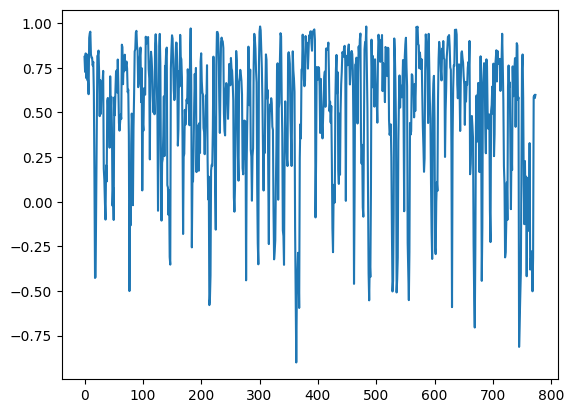

In [6]:
# plot the corr_mt for the first subject run UA tr 1

plt.plot(df.loc[0,'corr_mt'])


Text(0.5, 0.98, 'Subject sub-01, TR 0.5 s, Window size 6 vols, Step size 1 vols')

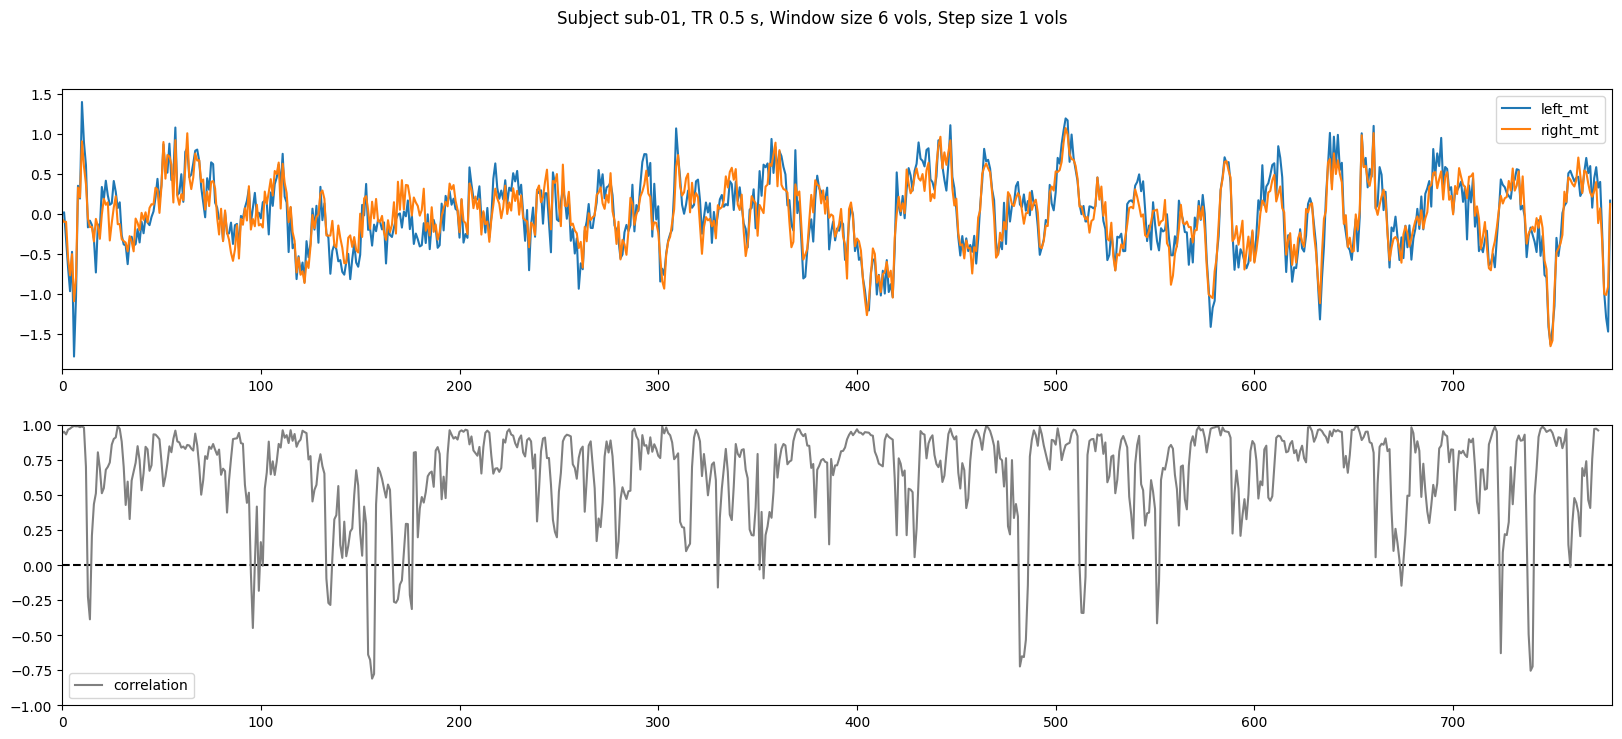

In [5]:
# Plot left v1, right v1 and correlation between them as 3 subplots
df_idx = 0

n_volumes = df.loc[df_idx,'left_v1'].shape[0]

fig, ax = plt.subplots(2,1,figsize=(20,8))
ax[0].plot(df.loc[df_idx,'left_v1'],label='left_mt')
ax[0].plot(df.loc[df_idx,'right_v1'],label='right_mt')
ax[0].legend()
ax[0].set_xlim([0,n_volumes])
ax[1].hlines(0,0,n_volumes,linestyle='dashed',color='black')
ax[1].plot(df.loc[df_idx,'corr_v1'],label='correlation',color='grey')
ax[1].legend()
ax[1].set_xlim([0,n_volumes])
ax[1].set_ylim([-1,1])

fig.suptitle(f"Subject {df.loc[df_idx,'subject']}, TR {df.loc[df_idx,'tr']} s, Window size {window_size_tr} vols, Step size {step_size_tr} vols")

Text(0.5, 0.98, 'Subject sub-01, TR 0.5 s, Window size 6 vols, Step size 1 vols')

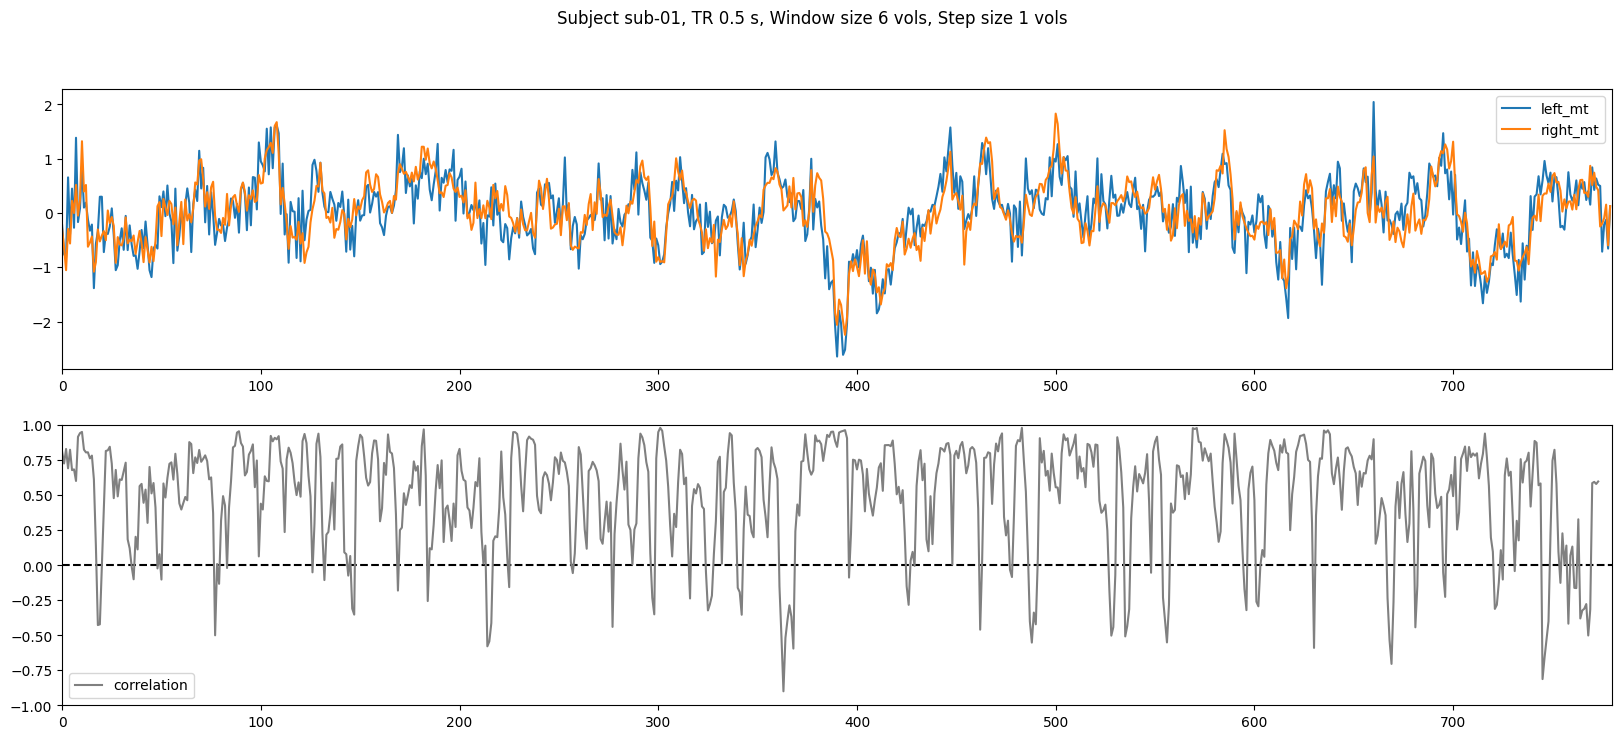

In [4]:
# Plot left mt, right mt and correlation between them as 3 subplots
df_idx = 0

n_volumes = df.loc[df_idx,'left_mt'].shape[0]

fig, ax = plt.subplots(2,1,figsize=(20,8))
ax[0].plot(df.loc[df_idx,'left_mt'],label='left_mt')
ax[0].plot(df.loc[df_idx,'right_mt'],label='right_mt')
ax[0].legend()
ax[0].set_xlim([0,n_volumes])
ax[1].hlines(0,0,n_volumes,linestyle='dashed',color='black')
ax[1].plot(df.loc[df_idx,'corr_mt'],label='correlation',color='grey')
ax[1].legend()
ax[1].set_xlim([0,n_volumes])
ax[1].set_ylim([-1,1])

fig.suptitle(f"Subject {df.loc[df_idx,'subject']}, TR {df.loc[df_idx,'tr']} s, Window size {window_size_tr} vols, Step size {step_size_tr} vols")

# centering at coherent switches

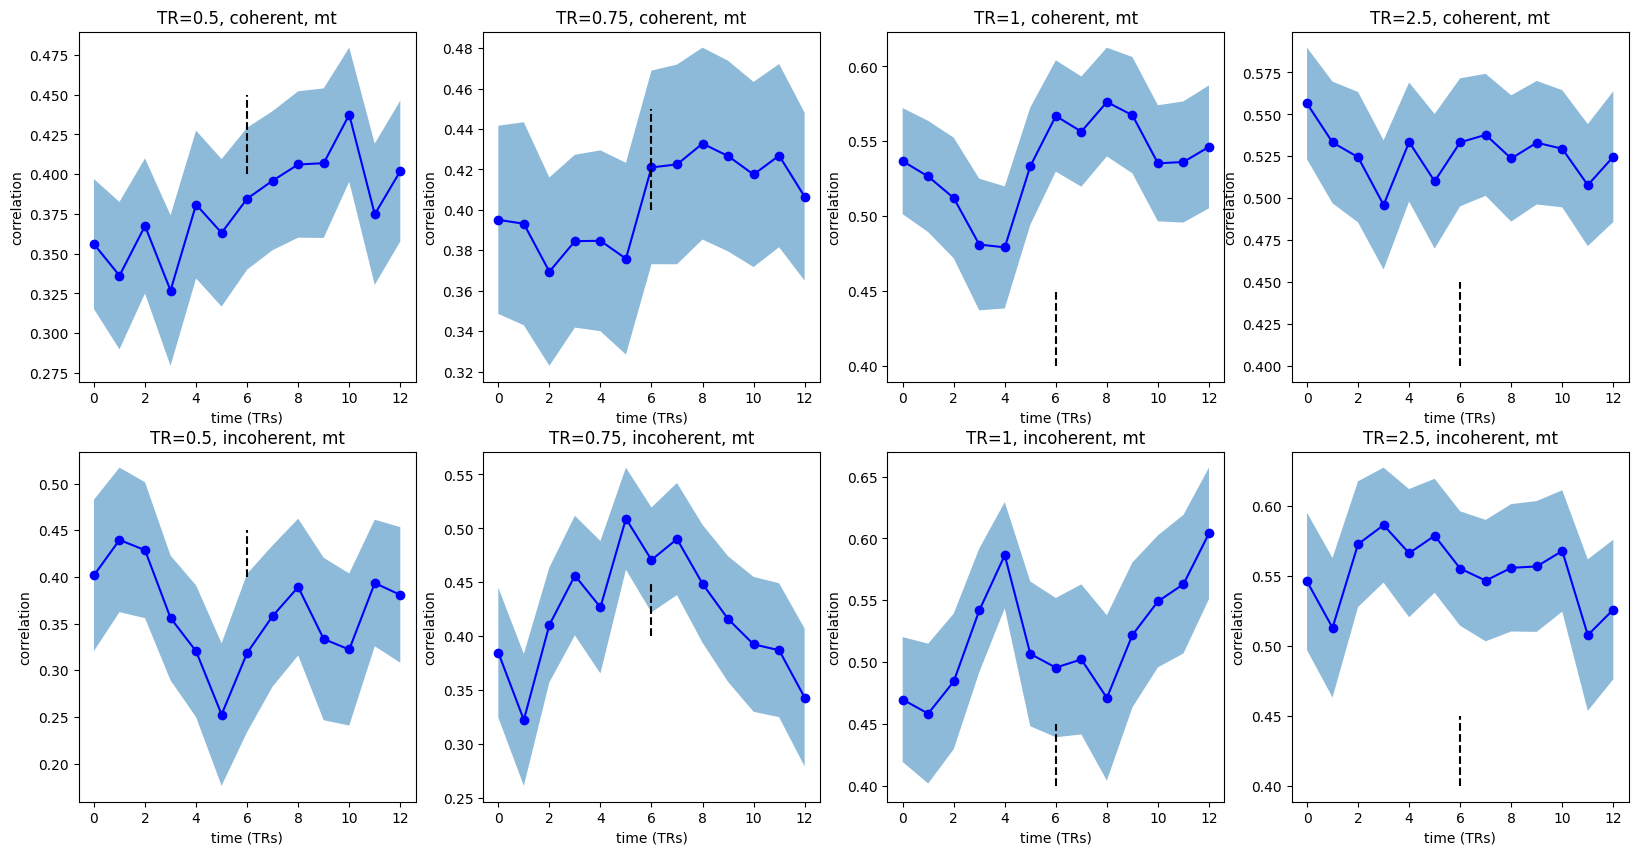

In [32]:
#tr = 1
trial_list = ['coherent','incoherent']
roi = 'mt'

# initialize figure with 4x2 subplot
fig, ax = plt.subplots(2,4,figsize=(20,10))

for tr_idx,tr in enumerate(tr_list):

    for trial_idx,trial in enumerate(trial_list):

        # calculate average of  for all rows
        aux = df.loc[df['tr']==tr,f'corr_{roi}_{trial}']

        # concatenate all rows
        aux = np.concatenate(aux.values)
        n_samples = aux.shape[0]

        # plot mean and std of aux in subplot
        plt.sca(ax[trial_idx,tr_idx])
        plt.plot(np.mean(aux,axis=0),color='blue', marker='o')
        plt.fill_between(range(aux.shape[1]),np.mean(aux,axis=0)-np.std(aux,axis=0)/np.sqrt(n_samples),np.mean(aux,axis=0)+np.std(aux,axis=0)/np.sqrt(n_samples),alpha=0.5)
        plt.vlines(window_size_tr,0.4,0.45,linestyle='dashed',color='black')
        #plt.text(8.5,0.7,trial)
        plt.ylabel('correlation')
        plt.xlabel('time (TRs)')
        plt.title(f"TR={tr}, {trial}, {roi}")

# legacy

Text(0, 0.5, 'correlation')

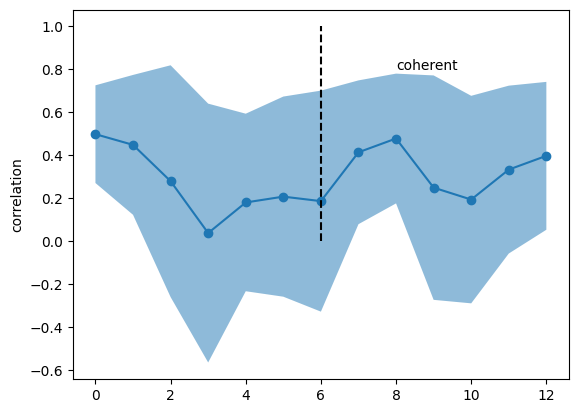

In [6]:
df_idx = 10

# plot average + sd of the n_coherent correlation trials
D = df.loc[df_idx,'corr_mt_coherent']

plt.plot(np.mean(D,axis=0),label='coherent',marker='o')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(D,axis=0)-np.std(D,axis=0),np.mean(D,axis=0)+np.std(D,axis=0),alpha=0.5)
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'coherent')
plt.ylabel('correlation')


Text(0, 0.5, 'correlation')

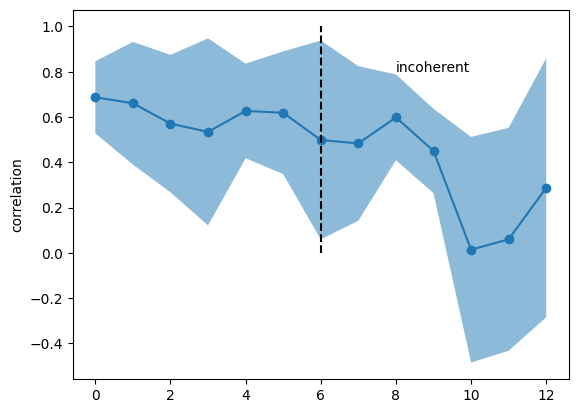

In [8]:
df_idx = 10

# plot average + sd of the n_coherent correlation trials
D = df.loc[df_idx,'corr_mt_incoherent']

plt.plot(np.mean(D,axis=0),label='incoherent',marker='o')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(D,axis=0)-np.std(D,axis=0),np.mean(D,axis=0)+np.std(D,axis=0),alpha=0.5)
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'incoherent')
plt.ylabel('correlation')

In [ ]:
# get the timecourse for the 6 points around the onset of the incoherent trials
# and plot the average timecourse for each trial type

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

corr = np.zeros((n_incoherent,window_size_tr*2+1))

for jj in range(n_incoherent):

    idx = incoherent_idx[jj]

    # left_mt timecourse
    a = tc[0,0][idx-window_size_tr:idx+window_size_tr*2]
    # right_mt timecourse
    b = tc[0,1][idx-window_size_tr:idx+window_size_tr*2]

    # correlation per window of window_size_tr
    for tt in range(0,window_size_tr*2+1):
        corr[jj,tt] = np.corrcoef(a[tt:tt+window_size_tr],b[tt:tt+window_size_tr])[0,1]
        
# plot average + sd of the n_coherent correlation trials
plt.plot(np.mean(corr,axis=0),label='incoherent',marker='o',color='red')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(corr,axis=0)-np.std(corr,axis=0),np.mean(corr,axis=0)+np.std(corr,axis=0),alpha=0.5,color='red')
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'incoherent')
plt.ylabel('correlation')
